# The Nth Asset — a quantitative teardown \U0001F52C
### Random-subset curves · the Elton-Gruber closed form · stopping rules · Meucci effective bets

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Usefulness: Fragile](https://img.shields.io/badge/Usefulness-Fragile-dab617?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). Two design
choices carry it: constituents are drawn **at random** rather than in a chosen order, so the
curve is an expectation rather than an anecdote; and the empirical curve is set against the
**closed form** so the reader can see that nothing beyond average correlation is doing the work.

> ⚠️ **Not investment advice.** Total-return closes from Yahoo! Finance pinned as-of the date
> in [`docs/results.md`](../docs/results.md).
>
> \U0001F4A1 **The `\U0001F4A1 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
from diversify_n import data, strategy as st

px = data.load_prices()
cash = px[data.CASH]
universe = [t for t in data.UNIVERSE if px[t].notna().sum() > 1000]
rets = st.excess_returns(px[universe], cash).dropna(how="any")
print(f"as-of {data.AS_OF} | {len(universe)} asset classes | "
      f"{rets.index[0].date()} -> {rets.index[-1].date()} ({len(rets):,} sessions)")
corr = rets.corr().to_numpy()
iu = np.triu_indices_from(corr, k=1)
print(f"average pairwise correlation: {corr[iu].mean():.3f}")

as-of 2026-06-30 | 12 asset classes | 2015-10-09 -> 2026-06-30 (2,695 sessions)
average pairwise correlation: 0.353


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | Real | A single randomly chosen asset from this universe ran **15.4%** annualised volatility; an equal-weight portfolio of all 12 runs **10.6%** — a **31%** reduction. The empirical curve tracks the textbook one (sigma^2 = sigma^2/k + rho·sigma^2·(k−1)/k) closely: average pairwise correlation is **0.35**, which puts the theoretical floor at **10.0%** — and the twelve-asset portfolio is already within 0.6% of it. |
| **Usefulness** | Fragile | Yes, and it is smaller than the industry implies. The third asset removes **9.0%** of the portfolio's volatility; the twelfth removes **0.6%**. At a 5% relative-improvement threshold the curve stops paying at **k = 3**; at 2% it stops at **k = 7**. And the count that matters is not the nominal one: 12 assets here are worth **1.4 effective bets**. Choosing well beats choosing many — the best 3-asset combination reached **6.2%** against **12.4%** for a random one of the same size. |

> \U0001F4A1 **In plain words.** The curve is the textbook one. What the textbook does not say
> is that the choice of constituents matters more than the count long before the curve
> flattens.

## 1 · The claim, as arithmetic

For k equally weighted assets with average variance σ² and average pairwise correlation ρ:

    Var(portfolio) = σ²/k + ρ·σ²·(k−1)/k  →  ρ·σ²  as k → ∞

- **H₁.** The empirical random-subset curve matches that expression.
- **H₂.** The limit — the average covariance — is a floor no count can pass.
- **H₃.** The dispersion across subsets of the same size exceeds the mean improvement from
  enlarging them, past a small k.

## 2 · The protocol

Constituents drawn at random (300 per size), equal weight, **drifting** between monthly
rebalances with 5 bps charged on the reset, all on excess-of-cash returns. The greedy ordering
is in-sample and labelled as a ceiling. Synthetic panels with known ρ bracket the machinery.

## 3 · The teardown

### 3.1 Empirical against closed form

    empirical  closed form   error
k                                 
1      0.1528       0.1680 -0.0902
2      0.1365       0.1382 -0.0121
3      0.1245       0.1267 -0.0170
4      0.1185       0.1205 -0.0170
5      0.1137       0.1167 -0.0252
6      0.1134       0.1140 -0.0056
7      0.1121       0.1121 -0.0003
8      0.1087       0.1107 -0.0181
9      0.1084       0.1095 -0.0105
10     0.1077       0.1086 -0.0084
11     0.1061       0.1078 -0.0163
12     0.1060       0.1072 -0.0108

average correlation 0.353, floor 9.98%


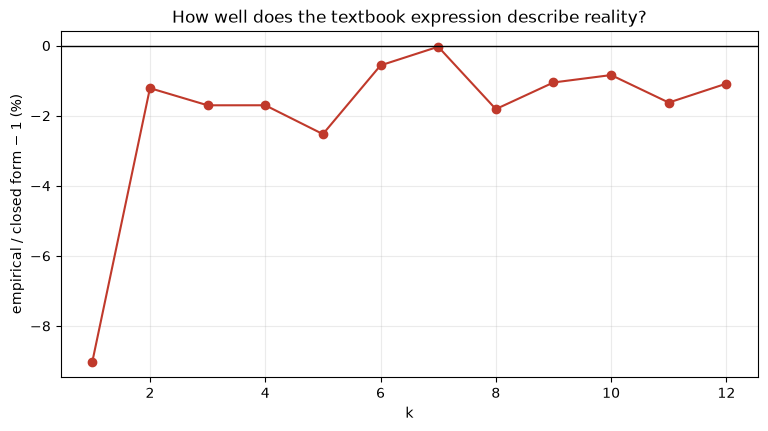

In [3]:
curve = st.random_subset_curve(rets, draws=250, cost_bps=5.0)
theory = st.theoretical_curve(rets)
cmp = pd.DataFrame({"empirical": curve["vol_mean"], "closed form": theory["vol_theory"]})
cmp["error"] = cmp["empirical"] / cmp["closed form"] - 1
print(cmp.round(4).to_string())
print(f"\naverage correlation {theory.attrs['avg_corr']:.3f}, "
      f"floor {theory.attrs['floor_vol']:.2%}")
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(cmp.index, cmp["error"] * 100, marker="o", color="#c0392b")
ax.axhline(0, color="k", lw=1)
ax.set_xlabel("k"); ax.set_ylabel("empirical / closed form − 1 (%)")
ax.set_title("How well does the textbook expression describe reality?")
plt.show()

### 3.2 Marginal benefit and the stopping rule

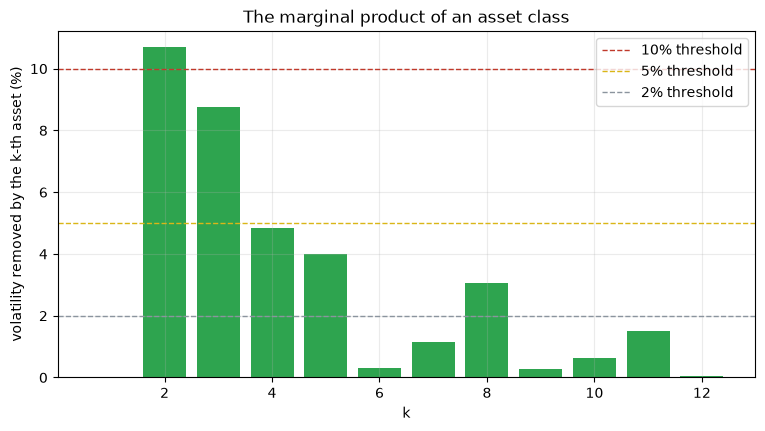

{'10%': 2, '5%': 3, '2%': 8, '1%': 11}


,vol,drop_abs,drop_rel,worth_it
k,,,,
1,0.1528,NaN,NaN,False
2,0.1365,0.0163,0.1069,True
3,0.1245,0.0120,0.0877,True
4,0.1185,0.0060,0.0486,False
5,0.1137,0.0047,0.0400,False
6,0.1134,0.0003,0.0029,False
7,0.1121,0.0013,0.0116,False
8,0.1087,0.0034,0.0306,False
9,0.1084,0.0003,0.0027,False


In [4]:
mb = st.marginal_benefit(curve, threshold=0.05)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(mb.index, mb["drop_rel"].fillna(0) * 100, color="#2ea44f")
for thr, col in ((0.10, "#c0392b"), (0.05, "#dab617"), (0.02, "#8b949e")):
    ax.axhline(thr * 100, color=col, ls="--", lw=1, label=f"{thr:.0%} threshold")
ax.set_xlabel("k"); ax.set_ylabel("volatility removed by the k-th asset (%)")
ax.legend(); ax.set_title("The marginal product of an asset class")
plt.show()
print({f"{thr:.0%}": st.stopping_point(curve, threshold=thr)
       for thr in (0.10, 0.05, 0.02, 0.01)})
mb.round(4)

> \U0001F4A1 **In plain words.** There is no objective stopping point — only a threshold you
> are willing to state. Saying it out loud is the whole contribution.

### 3.3 Which five beats how many

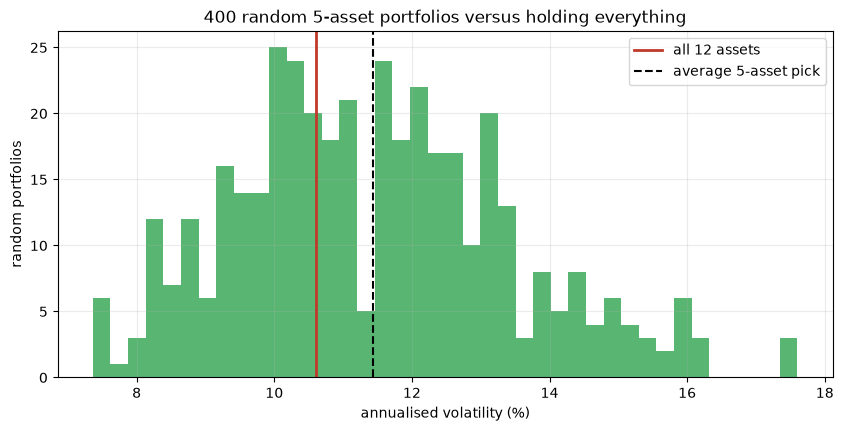

best  5-asset pick: 7.36% (DBC, GLD, HYG, IEF, LQD)
worst 5-asset pick: 17.60% (EEM, EFA, IWM, SPY, VNQ)
share of 5-asset picks that beat the full portfolio: 39.0%


In [5]:
k = min(5, len(universe))
rng = np.random.default_rng(974)
draws = []
for _ in range(400):
    pick = list(rng.choice(universe, size=k, replace=False))
    draws.append({"vol": st.portfolio_stats(rets[pick], cost_bps=5.0)["vol"],
                  "assets": ", ".join(sorted(pick))})
d = pd.DataFrame(draws)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(d["vol"] * 100, bins=40, color="#2ea44f", alpha=0.8)
ax.axvline(curve["vol_mean"].iloc[-1] * 100, color="#c0392b", lw=2,
           label=f"all {len(universe)} assets")
ax.axvline(d["vol"].mean() * 100, color="k", lw=1.5, ls="--", label=f"average {k}-asset pick")
ax.set_xlabel("annualised volatility (%)"); ax.set_ylabel("random portfolios")
ax.legend(); ax.set_title(f"400 random {k}-asset portfolios versus holding everything")
plt.show()
print(f"best  {k}-asset pick: {d.loc[d['vol'].idxmin(), 'vol']:.2%} "
      f"({d.loc[d['vol'].idxmin(), 'assets']})")
print(f"worst {k}-asset pick: {d.loc[d['vol'].idxmax(), 'vol']:.2%} "
      f"({d.loc[d['vol'].idxmax(), 'assets']})")
print(f"share of {k}-asset picks that beat the full portfolio: "
      f"{(d['vol'] < curve['vol_mean'].iloc[-1]).mean():.1%}")

### 3.4 The greedy ceiling

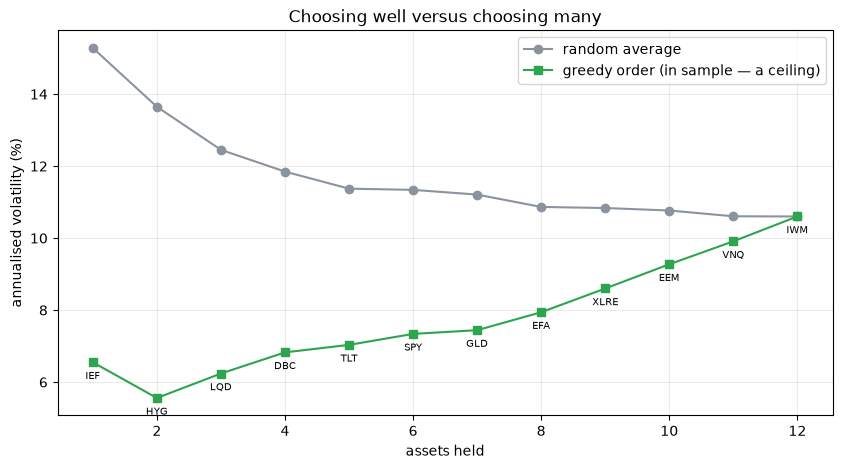

,added,vol,sharpe,max_dd,enb
k,,,,,
1,IEF,0.0655,-0.1179,-0.2769,1.0000
2,HYG,0.0556,0.1968,-0.1938,1.6272
3,LQD,0.0624,0.1808,-0.2179,1.0368
4,DBC,0.0683,0.3588,-0.1672,2.0033
5,TLT,0.0703,0.2360,-0.2102,1.1649
6,SPY,0.0734,0.4884,-0.1889,2.2944
7,GLD,0.0744,0.6143,-0.1702,2.3162
8,EFA,0.0794,0.6195,-0.1793,1.9702
9,XLRE,0.0860,0.5928,-0.1896,1.7876


In [6]:
order = st.greedy_order(rets, cost_bps=5.0)
g = st.ordered_curve(rets, order, cost_bps=5.0)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(curve.index, curve["vol_mean"] * 100, marker="o", color="#8b949e",
        label="random average")
ax.plot(g.index, g["vol"] * 100, marker="s", color="#2ea44f",
        label="greedy order (in sample — a ceiling)")
for k_, r_ in g.iterrows():
    ax.annotate(r_["added"], (k_, r_["vol"] * 100), fontsize=7, xytext=(0, -12),
                textcoords="offset points", ha="center")
ax.set_xlabel("assets held"); ax.set_ylabel("annualised volatility (%)")
ax.legend(); ax.set_title("Choosing well versus choosing many")
plt.show()
g.round(4)

### 3.5 Effective bets, and the two property funds

most redundant pairs:
  XLRE  / VNQ   0.977
  TLT   / IEF   0.914
  SPY   / IWM   0.865
  SPY   / EFA   0.846
  EFA   / EEM   0.829

most diversifying pairs:
  SPY   / IEF   -0.132
  IWM   / TLT   -0.134
  IEF   / DBC   -0.141
  SPY   / TLT   -0.158
  TLT   / DBC   -0.165


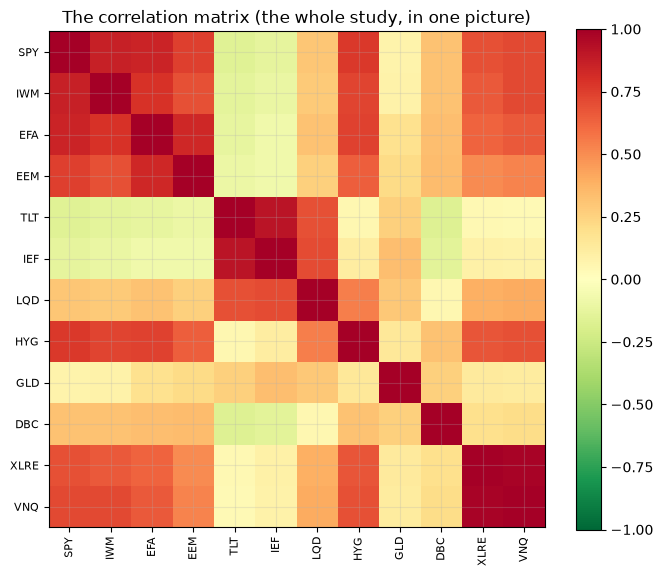


12 nominal assets = 1.40 effective bets


In [7]:
enb = pd.Series({k_: st.effective_number_of_bets(rets[universe[:k_]])
                 for k_ in range(1, len(universe) + 1)})
corr = rets.corr()
iu = np.triu_indices_from(corr.to_numpy(), k=1)
pairs = sorted([(universe[i], universe[j], corr.iloc[i, j]) for i, j in zip(*iu)],
               key=lambda t: -t[2])
print("most redundant pairs:")
for a, b, c in pairs[:5]:
    print(f"  {a:5s} / {b:5s} {c:.3f}")
print("\nmost diversifying pairs:")
for a, b, c in pairs[-5:]:
    print(f"  {a:5s} / {b:5s} {c:+.3f}")
fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(corr.to_numpy(), cmap="RdYlGn_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(universe))); ax.set_xticklabels(universe, rotation=90, fontsize=8)
ax.set_yticks(range(len(universe))); ax.set_yticklabels(universe, fontsize=8)
fig.colorbar(im, ax=ax)
ax.set_title("The correlation matrix (the whole study, in one picture)")
plt.show()
print(f"\n{len(universe)} nominal assets = {enb.iloc[-1]:.2f} effective bets")

### 3.6 The controls

In [8]:
rows = []
for rho in (0.0, 0.3, 0.6, 0.9):
    rng = np.random.default_rng(974)
    n, k = 4000, 8
    sd = 0.20 / np.sqrt(252)
    f = rng.normal(0, sd * np.sqrt(rho), (n, 1))
    sim = pd.DataFrame(f + rng.normal(0, sd * np.sqrt(1 - rho), (n, k)),
                       index=pd.bdate_range("2005-01-03", periods=n),
                       columns=[f"A{i}" for i in range(k)])
    c = st.random_subset_curve(sim, draws=40, cost_bps=0.0)
    rows.append({"rho": rho, "vol k=1": c.loc[1, "vol_mean"],
                 "vol k=8": c["vol_mean"].iloc[-1],
                 "reduction": 1 - c["vol_mean"].iloc[-1] / c.loc[1, "vol_mean"],
                 "effective bets": st.effective_number_of_bets(sim)})
pd.DataFrame(rows).set_index("rho").round(4)

,vol k=1,vol k=8,reduction,effective bets
rho,,,,
0.0000,0.1979,0.0703,0.6446,4.3557
0.3000,0.1993,0.1252,0.3719,1.0025
0.6000,0.2008,0.1629,0.1887,1.0003
0.9000,0.2024,0.1936,0.0434,1.0000


## 4 · The verdict

In [9]:
summary = pd.DataFrame({
    "vol, 1 asset": [curve.loc[1, "vol_mean"]],
    "vol, all assets": [curve["vol_mean"].iloc[-1]],
    "total reduction": [1 - curve["vol_mean"].iloc[-1] / curve.loc[1, "vol_mean"]],
    "theoretical floor": [theory.attrs["floor_vol"]],
    "stop at 5% threshold": [st.stopping_point(curve, threshold=0.05)],
    "effective bets (full)": [st.effective_number_of_bets(rets)],
}).T.rename(columns={0: "value"})
summary.round(4)

,value
"vol, 1 asset",0.1528
"vol, all assets",0.1060
total reduction,0.3063
theoretical floor,0.0998
stop at 5% threshold,3.0000
effective bets (full),1.3984


## 5 · Going further

- **Downside-conditional curves** (Ang & Chen 2002): rebuild the whole thing on the worst
  decile of market days and watch the floor rise.
- **Risk-weighted versions**: equal *risk* rather than equal capital changes both the curve and
  the stopping point.
- **Cost-aware stopping**: put a real operational cost per holding on the x-axis and the
  stopping rule becomes an optimisation rather than a threshold.
- **Regime conditioning**: the sample here is one correlation regime; 2000-2007 was another.